# 📓 Aprendizado por Reforço: Do Modelo ao Controle

[cite_start]Este notebook tem como objetivo explorar os principais algoritmos de Aprendizado por Reforço (RL) utilizando o ambiente **GridWorld**[cite: 83]. O projeto está dividido em módulos para facilitar a organização:
* [cite_start]`environment.py`: Lógica do ambiente e MDP[cite: 8, 9].
* [cite_start]`algorithms.py`: Implementação dos algoritmos de predição e controle[cite: 12, 14].
* [cite_start]`visualization.py`: Ferramentas para análise visual de resultados[cite: 16, 18].

## 1. Fundamentos e Configuração do Ambiente
Nesta seção, definimos o **MDP (Processo de Decisão de Markov)**. O agente interage com um grid onde cada movimento pode ser estocástico (ruído).

### A Matemática do Ambiente
O ambiente é definido pela tupla $\langle S, A, P, R, \gamma \rangle$:
* **Estados ($S$):** Coordenadas $(row, col)$ no grid.
* **Ações ($A$):** Norte, Sul, Leste e Oeste.
* **Transições $P(s' | s, a)$:** Probabilidade de chegar em $s'$ dado que a ação $a$ foi tomada em $s$. No nosso caso, o "ruído" define essa probabilidade.
* **Recompensas $R(s, a, s')$:** O retorno imediato, incluindo o "living reward" (custo de cada passo).

INFORMAÇÕES DO GRIDWORLD
Dimensões: 3 linhas x 4 colunas
Total de estados: 11
Paredes: 1
Estados terminais: 2
Fator de desconto (γ): 0.9
Ruído: 0.2
Living reward: -0.04
Ações disponíveis: ['N', 'S', 'L', 'O']

Paredes: [(1, 1)]

Estados terminais:
  (0, 3): reward = 1.0
  (1, 3): reward = -1.0


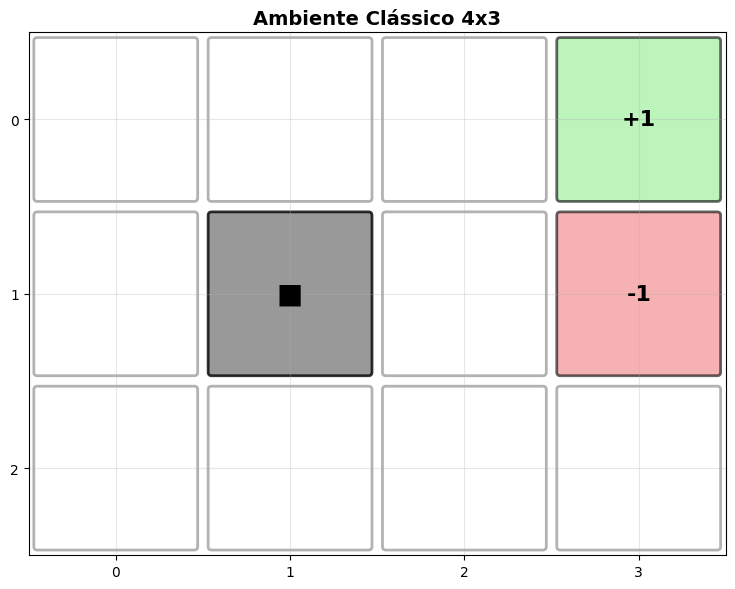

In [1]:
# Importações iniciais
from environment import create_classic_gridworld, print_gridworld_info
from visualization import visualize_gridworld
import numpy as np

# Instanciando o GridWorld 4x3 clássico (Russell & Norvig)
gw = create_classic_gridworld()
print_gridworld_info(gw)

# Visualização Inicial
visualize_gridworld(gw, title="Ambiente Clássico 4x3")

## 2. Programação Dinâmica (Model-Based)
Na Programação Dinâmica, assumimos que o agente conhece perfeitamente o modelo do mundo ($P$ e $R$).

### 2.1 Avaliação de Política (Policy Evaluation)
Para uma política fixa $\pi$, queremos encontrar a função valor $V^\pi(s)$, que resolve a **Equação de Bellman**:

$$V^\pi(s) = \sum_{a \in A} \pi(a|s) \sum_{s', r} p(s', r | s, a) [r + \gamma V^\pi(s')]$$

Abaixo, avaliamos uma **política uniforme**, onde o agente escolhe qualquer direção com 25% de probabilidade.

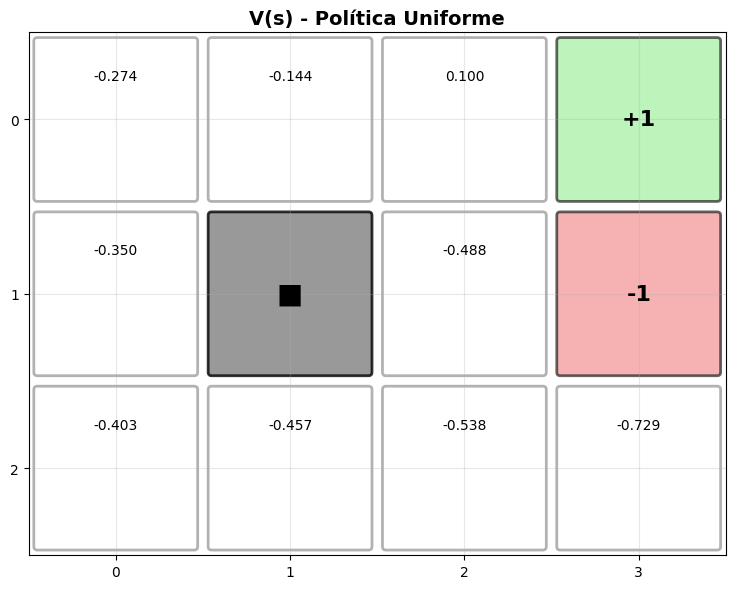

In [3]:
from algorithms import iter_policy_eval_vec
from visualization import convert_dp_v_to_dict

# Definindo uma política uniforme (25% para cada direção)
nb_states = gw.nb_states
nb_actions = gw.nb_actions
uniform_policy = np.ones([nb_states, nb_actions]) / nb_actions

# Avaliando a política usando a versão vetorizada
V_uniform = iter_policy_eval_vec(gw, uniform_policy, gamma=gw.gamma, theta=1e-4)

# Visualizando os valores V(s) sob a política uniforme
V_dict = convert_dp_v_to_dict(V_uniform, gw)
visualize_gridworld(gw, values=V_dict, title="V(s) - Política Uniforme")

### 2.2 Value Iteration
O algoritmo **Value Iteration** busca a função valor ótima $V^*(s)$ de forma iterativa, aplicando o princípio da otimalidade de Bellman:

$$V_{k+1}(s) = \max_{a} \sum_{s', r} p(s', r | s, a) [r + \gamma V_k(s')]$$

Ao final das iterações, a política ótima $\pi^*$ é extraída de forma gulosa em relação aos valores calculados.

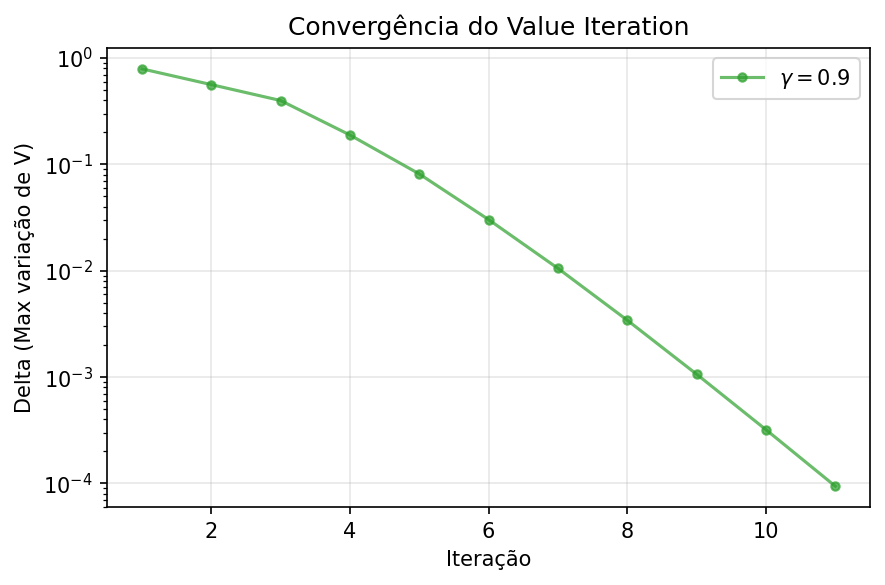

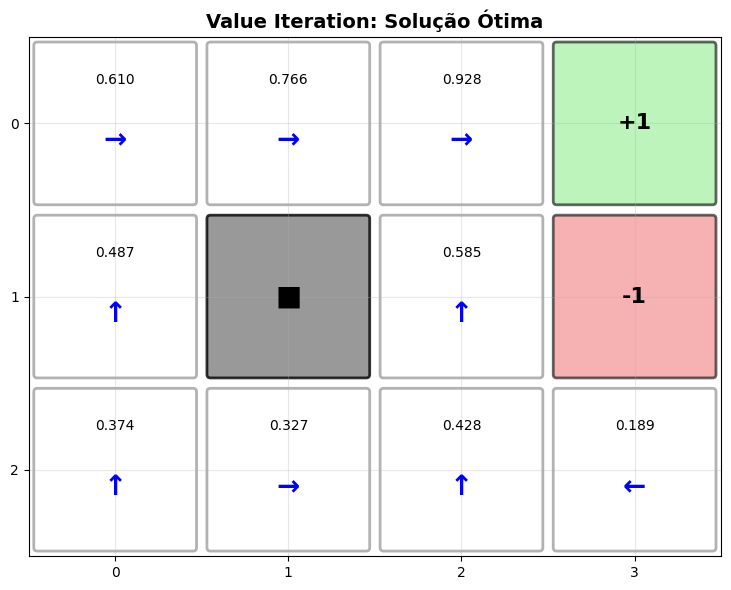

In [4]:
from algorithms import value_iteration
from visualization import convert_dp_v_to_dict, convert_dp_policy_to_dict, plot_value_iteration_convergence

# Executando o algoritmo (Calcula V e extrai a política)
V_star, policy_star, delta_history = value_iteration(gw, gamma=0.9, theta=1e-4)

# Gráfico de Convergência (Delta decaindo logaritmicamente)
plot_value_iteration_convergence(delta_history, gamma=0.9)

# Convertendo dados para visualização no grid
V_opt_dict = convert_dp_v_to_dict(V_star, gw)
pol_opt_dict = convert_dp_policy_to_dict(policy_star, gw)

visualize_gridworld(gw, values=V_opt_dict, policy=pol_opt_dict, title="Value Iteration: Solução Ótima")

### 2.3 Policy Iteration
O **Policy Iteration** alterna entre dois passos principais:
1.  **Avaliação:** Calcula $V^\pi$ até a convergência para a política atual.
2.  **Melhoria:** Atualiza a política $\pi$ para ser gulosa em relação a $V^\pi$.

Este processo garante a convergência para a política ótima em um número finito de passos.

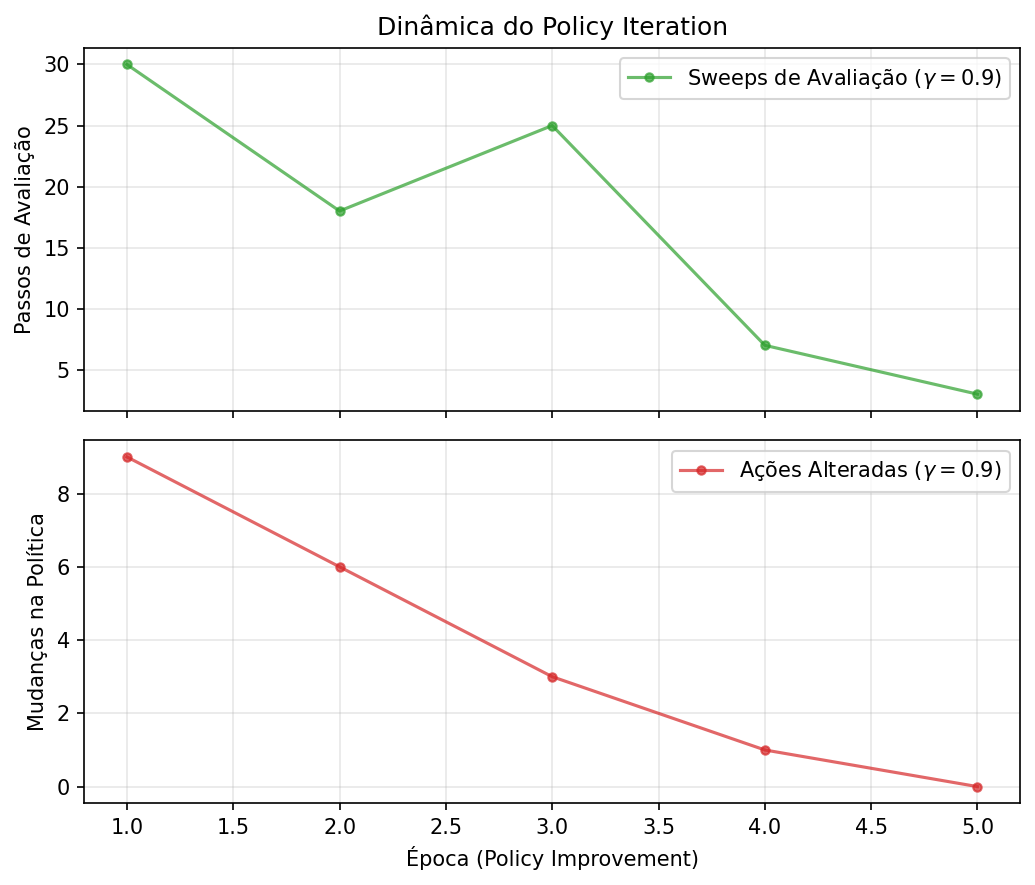

In [5]:
from algorithms import policy_iteration
from visualization import plot_policy_iteration_convergence

# Executa Policy Iteration
V_pi, policy_pi, eval_history, change_history = policy_iteration(gw, gamma=0.9)

# Visualizando o esforço computacional
plot_policy_iteration_convergence(eval_history, change_history, gamma=0.9)

## 3. Avaliação de Política (Model-Free Prediction)
Na vida real, um agente geralmente não conhece as probabilidades de transição $P$ e a função de recompensa $R$ do ambiente. Ele precisa aprender **por experiência** (tentativa e erro).

Esta seção cobre algoritmos **Model-Free** para predição: estimar $V^\pi(s)$ seguindo uma política fixa $\pi$, baseando-se apenas nas amostras de trajetórias.

### 3.1 TD(0) vs. Monte Carlo
* **Monte Carlo (First-Visit):** Atualiza os valores apenas no final de um episódio, usando o retorno total $G_t$.
  $$V(S_t) \leftarrow V(S_t) + \alpha [G_t - V(S_t)]$$
* **Temporal Difference - TD(0):** Atualiza os valores a cada passo (online), fazendo um "bootstrap" com a estimativa do próximo estado.
  $$V(S_t) \leftarrow V(S_t) + \alpha [R_{t+1} + \gamma V(S_{t+1}) - V(S_t)]$$

Vamos criar uma política simples (ir sempre para o Norte) e comparar como os dois algoritmos estimam o valor dos estados no GridWorld clássico.

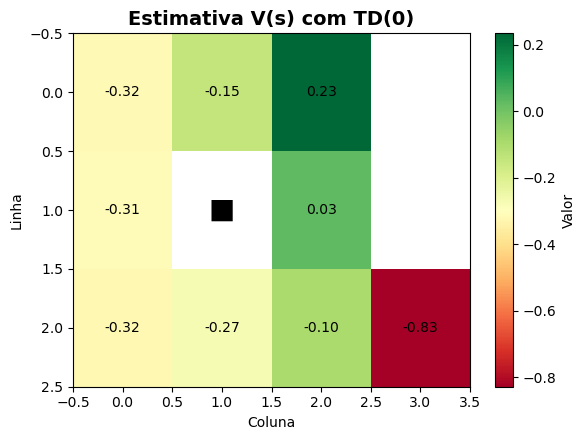

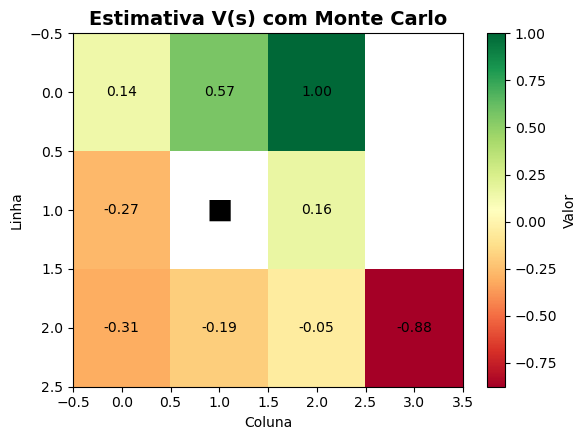

In [5]:
from algorithms import td_zero_prediction, first_visit_mc_prediction
from visualization import plot_value_heatmap

# Definindo uma política determinística simples: Ir para o Norte ('N') sempre
policy_north = {s: 'N' for s in gw.states if not gw.is_terminal(s)}

# Executando TD(0) e Monte Carlo
V_td = td_zero_prediction(gw, policy_north, n_episodes=2000, alpha=0.05)
V_mc = first_visit_mc_prediction(gw, policy_north, n_episodes=2000, alpha=0.05)

# Comparando visualmente os resultados
plot_value_heatmap(V_td, gw, title="Estimativa V(s) com TD(0)")
plot_value_heatmap(V_mc, gw, title="Estimativa V(s) com Monte Carlo")

## 4. Controle via Diferença Temporal (TD Control)
Agora queremos que o agente **encontre a política ótima** $\pi^*$ sem conhecer o modelo. Para isso, aprendemos os valores de ação-estado $Q(s, a)$.

Vamos comparar três algoritmos clássicos no ambiente **Cliff World**, onde o agente precisa contornar um precipício (recompensa altamente negativa) para chegar ao objetivo.

### A Matemática do Controle
1. **SARSA (On-policy):** Aprende o valor da política $\epsilon$-greedy que está executando.
   $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]$$

2. **Q-Learning (Off-policy):** Aprende o valor da política ótima (usando o máximo), mesmo enquanto explora de forma $\epsilon$-greedy.
   $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t)]$$

3. **Expected SARSA:** Usa a expectativa de $Q$ sob a política atual para reduzir a variância, sendo um "meio-termo" poderoso.
   $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma \sum_a \pi(a|S_{t+1}) Q(S_{t+1}, a) - Q(S_t, A_t)]$$

INFORMAÇÕES DO GRIDWORLD
Dimensões: 4 linhas x 8 colunas
Total de estados: 32
Paredes: 0
Estados terminais: 7
Fator de desconto (γ): 0.9
Ruído: 0.0
Living reward: -1.0
Ações disponíveis: ['N', 'S', 'L', 'O']

Estados terminais:
  (3, 1): reward = -100.0
  (3, 2): reward = -100.0
  (3, 3): reward = -100.0
  (3, 4): reward = -100.0
  (3, 5): reward = -100.0
  (3, 6): reward = -100.0
  (3, 7): reward = 0.0


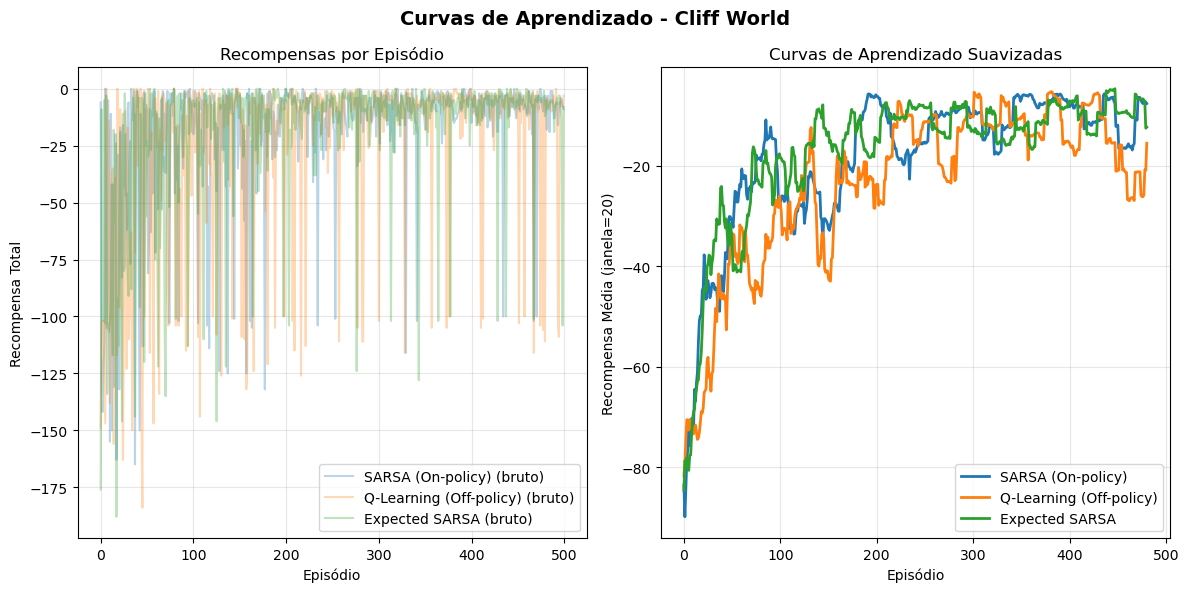

In [6]:
from environment import create_cliff_world_2, print_gridworld_info
from algorithms import sarsa, q_learning, expected_sarsa
from visualization import plot_learning_curves

# Criando o ambiente do Precipício (Cliff World)
cliff_env = create_cliff_world_2(noise=0.0) # Ambiente determinístico para destacar a política
print_gridworld_info(cliff_env)

# Treinando os algoritmos (500 episódios)
alpha_lr = 0.1
eps = 0.1
episodes = 500

Q_sarsa, rw_sarsa = sarsa(cliff_env, n_episodes=episodes, alpha=alpha_lr, epsilon=eps)
Q_ql, rw_ql = q_learning(cliff_env, n_episodes=episodes, alpha=alpha_lr, epsilon=eps)
Q_es, rw_es = expected_sarsa(cliff_env, n_episodes=episodes, alpha=alpha_lr, epsilon=eps)

# Plotando as curvas de aprendizado
plot_learning_curves({
    'SARSA (On-policy)': rw_sarsa,
    'Q-Learning (Off-policy)': rw_ql,
    'Expected SARSA': rw_es
}, window=20, title="Curvas de Aprendizado - Cliff World")